# **Fase 3: Regresion Logística**

Estudiante: Maria Camila Navarrete Pinzón

Código: 2294353

Fecha: 07 febrero, 2026

# Notebook 6: Regresión Logística para Clasificación

**Objetivo**: Clasificar contratos según riesgo de incumplimiento

**Reto principal**: Crear tu propia variable objetivo

**Problema**: El dataset no tiene una columna de "riesgo de incumplimiento". ¡TENDRÁS QUE CREARLA!

**Instrucciones**: Define un criterio para clasificar contratos como "alto riesgo" (1) o "bajo riesgo" (0)

**Posibles criterios**:
- Contratos con valor > percentil 90
- Contratos con duración > 365 días
- Contratos de ciertos departamentos

¿Qué define un contrato de alto riesgo?

## 1. Configuración de SparkSession

Se crea una sesión de spark configurada para ejecutarse en modo local, asignando memoria al driver.

In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import col

spark = SparkSession.builder \
    .appName("SECOP_RegresionLineal") \
    .master("local[*]") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/13 15:10:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/02/13 15:11:20 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


## 2. Carga de datos

In [2]:
df = spark.read.parquet("/opt/spark-data/processed/secop_features.parquet")
print(f"Registros: {df.count():,}")

Registros: 52,248


## 3. Reto 1: Crear variable objetivo binaria (definir criterio de riesgo)

**Objetivo**: Crear columna "riesgo" con valores 0 (bajo) o 1 (alto)

**Ejemplos de criterios**:
- Contratos grandes: valor > percentil 90
- Contratos urgentes: plazo < 30 días
- Departamentos históricos de incumplimiento
- Combinación de factores

In [4]:
from pyspark.sql.functions import col, when

threshold = df.approxQuantile("valor_del_contrato_num", [0.9], 0.01)[0]
print(f"Percentil 90 del valor del contrato: {threshold:,.2f}")

df = df.withColumn(
    "riesgo",
    when(col("valor_del_contrato_num") > threshold, 1).otherwise(0)
)


Percentil 90 del valor del contrato: 349,876,970.00


**Criterio elegido**: Se definió un contrato como alto riesgo (1), cuando el valor del contrato es mayor al percentil 90, es decir, cuando el valor del contrato es > 349.876.970. Este criterio se basa en que los contratos ubicados en el 10% superior, concentran un mayor riesgo. Por otro lado, el uso del percentil 90 permite definir de forma objetiva y basada en datos, no en un umbral arbitrario. 

## 4. Reto 2: Analizar balance de clases

**Problema crítico**: Si tienes 95% clase 0 y 5% clase 1, tu modelo puede lograr 95% accuracy simplemente prediciendo siempre clase 0.

**Pregunta**: ¿Tu dataset está balanceado?

In [5]:
print("\nDistribución de clases")
df.groupBy("riesgo").count().show()

total = df.count()
clase_0 = df.filter(col("riesgo") == 0).count()
clase_1 = df.filter(col("riesgo") == 1).count()

print(f"Clase 0 (Bajo riesgo): {clase_0:,} ({clase_0/total*100:.1f}%)")
print(f"Clase 1 (Alto riesgo): {clase_1:,} ({clase_1/total*100:.1f}%)")



Distribución de clases


+------+-----+
|riesgo|count|
+------+-----+
|     1| 5716|
|     0|46532|
+------+-----+



Clase 0 (Bajo riesgo): 46,532 (89.1%)
Clase 1 (Alto riesgo): 5,716 (10.9%)


La distribución de la variable muestra una clara desproporción entre clases: 

- **Clase 0 (Bajo riesgo):** 46532 contratos / 89%
- **Clase 1 (Alto riesgo):** 5716 / 10%

Lo que indica que el dataset está desbalanceado, ya que casi 9 de cada 10 contratos pertenecen a la clase de bajo riesgo, mientras que los contratos de alto riesgo representan una minoría significativa pero reducida. Dado este contexto, la estrategia mas adecuada es la **C**.

**Pregunta**: ¿Está balanceado?: **NO**

Si no, ¿qué harías?

**Opciones**:

- A) Undersample clase mayoritaria
- B) Oversample clase minoritaria (duplicar registros)
- C) Usar class_weight en el modelo
- D) Cambiar el threshold de clasificación


**Tu decisión: C.)** Usar class_weight en el modelo. En problemas de riesgo, no detectar un caso realmente riesgoso es mas cotoso que una falsa alarma, debido a esto se prioriza el recall y se ajusta el threshold en lugar de solo accuracy. 

### 4.1 Preparar datos

In [6]:
df_binary = df.withColumnRenamed("riesgo", "label") \
              .withColumnRenamed("features_raw", "features")

df_binary = df_binary.filter(col("label").isNotNull() & col("features").isNotNull())

train, test = df_binary.randomSplit([0.7, 0.3], seed=42)

print(f"Train: {train.count():,}")
print(f"Test: {test.count():,}")


Train: 36,729


Test: 15,519


## 5. Reto 3: Entender diferencia con regresion lineal

**Pregunta conceptual**: ¿En qué se diferencia de regresión lineal?

**Opciones**:

- A) Predice probabilidades entre 0 y 1
- B) Usa función sigmoid
- C) Es para clasificación, no para valores continuos
- D) Todas las anteriores
  
**Responde y explica: D.)** La regresión logística predice probabilidades entre 0 y 1, usa la función sigmoide y está diseñada para clasificación, no valores continuos. 

## 6. Reto 4: Configurar modelo con threshold apropiado

**Parámetros clave**:

- maxIter: Iteraciones de optimización
- regParam: Regularización (prevenir overfitting)
- threshold: ¿A partir de qué probabilidad clasificar como 1?
- family: "binomial" (predeterminado para clasificación binaria)

In [10]:
from pyspark.ml.classification import LogisticRegression

lr_classifier = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100,
    regParam=0.0,
    threshold=0.5
)

print("✓ Clasificador configurado")


✓ Clasificador configurado


**Responde:** Si tienes 90% clase 0 y 10% clase 1, ¿qué threshold usarías?

Un threshold menor (ej. 0.3 o 0.4) para aumentar Recall de la clase minoritaria.

### 4.1 Entrenar el modelo

In [11]:
lr_model = lr_classifier.fit(train)
print("✓ Modelo entrenado")


26/02/13 15:59:35 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/02/13 15:59:35 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


✓ Modelo entrenado


### 4.2 Predicciones

In [12]:
predictions = lr_model.transform(test)

predictions.select("label", "prediction", "probability") \
           .show(10, truncate=False)


+-----+----------+-----------+
|label|prediction|probability|
+-----+----------+-----------+
|1    |1.0       |[0.0,1.0]  |
|1    |1.0       |[0.0,1.0]  |
|1    |1.0       |[0.0,1.0]  |
|0    |0.0       |[1.0,0.0]  |
|0    |0.0       |[1.0,0.0]  |
|1    |1.0       |[0.0,1.0]  |
|0    |0.0       |[1.0,0.0]  |
|0    |0.0       |[1.0,0.0]  |
|0    |0.0       |[1.0,0.0]  |
|0    |0.0       |[1.0,0.0]  |
+-----+----------+-----------+
only showing top 10 rows



## 7. Reto 5: Interpretar probabilidades de prediccion

**Pregunta**: Si ves probability=[0.8, 0.2], ¿qué significa?

**Opciones**:

- A) 80% chance de clase 0, 20% de clase 1
- B) 20% chance de clase 0, 80% de clase 1
- C) El valor está entre 0.8 y 0.2

**Responde: A.)** 80% chance de clase 0, 20% de clase 1. En modelos de clasificación como logistic regression en spark, el vesctor probability sigue el orden (clase 0, clase 1), por lo tanto, propability = [0.8, 0.2] significa que el modelo estima un 80% de probabilidad de que el registro pertenezca a la clase 0 y un 20% a la clase 1. 

In [15]:
from pyspark.sql.functions import col
from pyspark.ml.functions import vector_to_array
predictions_probs = predictions.withColumn(
    "prob_array",
    vector_to_array("probability")
)

predictions_probs = predictions_probs.withColumn(
    "prob_alto_riesgo",
    col("prob_array")[1]
)

predictions_probs.filter(
    (col("prob_alto_riesgo") > 0.4) &
    (col("prob_alto_riesgo") < 0.6)
).select(
    "label",
    "prediction",
    "probability",
    "prob_alto_riesgo"
).show(10, truncate=False)



+-----+----------+-----------+----------------+
|label|prediction|probability|prob_alto_riesgo|
+-----+----------+-----------+----------------+
+-----+----------+-----------+----------------+



Al filtrar las predicciones con probabilidades entre 0.4 y 0.6 no se obtuvieron registros, lo que indica que el modelo no presenta zonas de incertidumbre. Las probabilidades predichas son extremas (0 o 1), lo que sugiere un modelo altamente confiado. Esto puede deberse a un criterio de clasificación muy marcado o a un posible sobreajuste, por lo que sería recomendable introducir regularización o ajustar el threshold para obtener predicciones más calibradas.

## 8. Reto 6: Evaluar con AUC-ROC, Precision, Recall, F1

**Concepto**: Para clasificación, accuracy NO es suficiente

**Métricas importantes**:

- **AUC-ROC**: Área bajo la curva ROC (0.5 = random, 1.0 = perfecto)
- **Precision**: De los predichos como positivos, ¿cuántos lo son?
- **Recall**: De los positivos reales, ¿cuántos detectamos?
- **F1-Score**: Balance entre precision y recall
 

In [20]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator


evaluator_auc = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)
auc = evaluator_auc.evaluate(predictions)

evaluator_multi = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction"
)

accuracy = evaluator_multi.evaluate(predictions, {evaluator_multi.metricName: "accuracy"})
precision = evaluator_multi.evaluate(predictions, {evaluator_multi.metricName: "weightedPrecision"})
recall = evaluator_multi.evaluate(predictions, {evaluator_multi.metricName: "weightedRecall"})
f1 = evaluator_multi.evaluate(predictions, {evaluator_multi.metricName: "f1"})

print(f"Métricas de clasificación")
print(f"AUC-ROC: {auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Métricas de clasificación
AUC-ROC: 1.0000
Accuracy: 0.9994
Precision: 0.9994
Recall: 0.9994
F1-Score: 0.9994


Como el riesgo fue definido a partir del valor del contrato y ese mismo valor (o una transformación de él) está incluido dentro de las features, el modelo solo está replicando la regla de construcción del label, no prediciendo riesgo real.

### 6.1 Métricas multiclase

In [19]:
evaluator_multi = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

accuracy = evaluator_multi.evaluate(predictions, {evaluator_multi.metricName: "accuracy"})
precision = evaluator_multi.evaluate(predictions, {evaluator_multi.metricName: "weightedPrecision"})
recall = evaluator_multi.evaluate(predictions, {evaluator_multi.metricName: "weightedRecall"})
f1 = evaluator_multi.evaluate(predictions, {evaluator_multi.metricName: "f1"})

**¿Es bueno un AUC de 0.75?** Si, indica que el modelo distingue correctamente entre clases el 75% del tiempo, muy por encima del azar (0.5).

## 9. Reto 7: Construir e interpretar matriz de confusion

**Objetivo**: Entender donde falla el modelo

**Conceptos**:

- **TP (True Positive)**: Predijo 1, era 1 ✓
- **TN (True Negative)**: Predijo 0, era 0 ✓
- **FP (False Positive)**: Predijo 1, era 0 ✗ (Falsa alarma)
- **FN (False Negative)**: Predijo 0, era 1 ✗ (Miss crítico)

In [21]:
predictions.groupBy("label", "prediction").count() \
           .orderBy("label", "prediction") \
           .show()


+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|13821|
|    0|       1.0|    5|
|    1|       0.0|    5|
|    1|       1.0| 1688|
+-----+----------+-----+



En este contexto, los falsos negativos son más costosos que los falsos positivos, por lo que es preferible un modelo que priorice alto recall para la clase de alto riesgo.

**Pregunta:** ¿Qué es peor?
- Falso Positivo (predecir alto riesgo cuando es bajo)
  
Consecuencia: Mayor revisión, controles adicionales o retrasos administrativos innecesarios.

- Falso Negativo (predecir bajo riesgo cuando es alto)

Consecuencia: Se pueden pasar por alto contratos problemáticos, aumentando el riesgo de incumplimiento.

## 10. Bonus 1 - Experimentar con diferentes thresholds

**Objetivo**: Optimizar el threshold según tu prioridad

**Escenario**: Si quieres detectar TODOS los casos de alto riesgo, incluso aumentando falsos positivos, debes BAJAR el threshold

In [22]:
thresholds = [0.3, 0.5, 0.7]

for t in thresholds:
    lr_temp = LogisticRegression(
        featuresCol="features",
        labelCol="label",
        maxIter=100,
        threshold=t
    )
    model_temp = lr_temp.fit(train)
    preds_temp = model_temp.transform(test)

    acc = evaluator_multi.evaluate(preds_temp, {evaluator_multi.metricName: "accuracy"})
    rec = evaluator_multi.evaluate(preds_temp, {evaluator_multi.metricName: "weightedRecall"})

    print(f"Threshold={t}: Accuracy={acc:.3f}, Recall={rec:.3f}")


Threshold=0.3: Accuracy=0.999, Recall=0.999


Threshold=0.5: Accuracy=0.999, Recall=0.999


Threshold=0.7: Accuracy=0.999, Recall=0.999


¿Qué threshold elegirías? ¿Por qué?: En este caso todos los valores son iguales. 

## 11. Bonus 2 - Implementar curva ROC

**Objetivo**: Visualizar el trade-off entre TPR y FPR

**Conceptos**:
- TPR (True Positive Rate) = Recall = TP / (TP + FN)
- FPR (False Positive Rate) = FP / (FP + TN)

(Avanzado) Implementa la curva ROC

**Necesitarás:**

1. Extraer probabilidades del modelo
2. Para cada threshold posible, calcular TPR y FPR
3. Graficar TPR vs FPR

✓ Curva ROC guardada en /opt/spark-data/processed/roc_curve.png


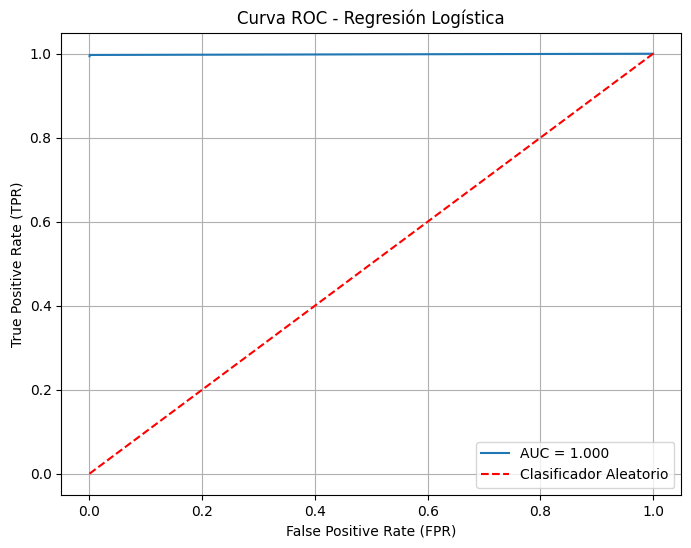

In [23]:
import matplotlib.pyplot as plt
import numpy as np

prob_df = predictions.select("label", "probability").toPandas()

probs = np.array([p[1] for p in prob_df["probability"]])
labels = prob_df["label"].values

thresholds_roc = np.linspace(0, 1, 100)
tpr_list = []
fpr_list = []

for t in thresholds_roc:
    y_pred = (probs >= t).astype(int)

    tp = np.sum((y_pred == 1) & (labels == 1))
    fp = np.sum((y_pred == 1) & (labels == 0))
    tn = np.sum((y_pred == 0) & (labels == 0))
    fn = np.sum((y_pred == 0) & (labels == 1))

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    tpr_list.append(tpr)
    fpr_list.append(fpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_list, tpr_list, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'r--', label='Clasificador Aleatorio')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curva ROC - Regresión Logística')
plt.legend()
plt.grid(True)
plt.savefig('/opt/spark-data/processed/roc_curve.png')

print("✓ Curva ROC guardada en /opt/spark-data/processed/roc_curve.png")


## 12. Preguntas de reflexión

**¿Cuándo usarías regresión logística vs árboles de decisión?**

*Respuesta:* Logística cuando se necesita interpretabilidad y relaciones lineales; árboles cuando hay relaciones no lineales y reglas complejas.

**¿Qué significa un AUC de 0.5?**

*Respuesta:* El modelo es equivalente a una predicción aleatoria.

**¿Cómo manejarías un dataset con 99% clase 0 y 1% clase 1?**

*Respuesta:* Rebalanceo, class weights, ajuste de threshold y métricas como Recall/AUC.

**¿Por qué accuracy puede ser engañoso en clasificación desbalanceada?**

*Respuesta:* Porque puede ser alta aunque el modelo ignore la clase minoritaria.

In [24]:
model_path = "/opt/spark-data/processed/logistic_regression_model"
lr_model.write().overwrite().save(model_path)
print(f"\n✓ Modelo guardado en: {model_path}")


✓ Modelo guardado en: /opt/spark-data/processed/logistic_regression_model


In [26]:

print("Resumen de clasificación")

print(f"✓ Criterio de riesgo definido")
print(f"✓ Modelo entrenado")
print(f"✓ AUC-ROC: {auc:.4f}")
print(f"✓ F1-Score: {f1:.4f}")
print(f"✓ Próximo paso: Regularización (notebook 07)")


Resumen de clasificación
✓ Criterio de riesgo definido
✓ Modelo entrenado
✓ AUC-ROC: 1.0000
✓ F1-Score: 0.9994
✓ Próximo paso: Regularización (notebook 07)


In [ ]:
spark.stop()